# <span style="color: rgba(230, 0, 126, 1);"> BANK MARKETING </span> #

### <span style="color: rgba(230, 0, 126, 1);"> 1.- Importación de librerias para el análisis de datos </span> ###

In [3]:
# importación de librerias para el análisis de datos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### <span style="color: rgba(230, 0, 126, 1);"> 2.- Carga de datos desde archivo CSV original </span> ###

In [4]:
# la r al inicio cambia el sentido de la contrabarra en el path del repositorio local copiada directamente del explorador de windows. sep0";" indica como están separados los campos en el archivo csv"
df=pd.read_csv(r"C:\MNG\03_IT Academy\04_Simulador empresarial (SE)\ProjecteData\251027_MNG_W01\251027_tabla BANK_marketing(original).csv",sep=";")

### <span style="color: rgba(230, 0, 126, 1);"> 3.- Exploración de los datos cargados </span> ###

In [ ]:
# conocer la dimensión de la tabla y a la vez tener una idea del nombre de los atributos-campos- y valores de los registros-filas-
print(df.shape)
df.head()

In [ ]:
# conocer que variables son numéricas y que variables son categóricas
df.info()

### <span style="color: rgba(230, 0, 126, 1);"> 4.- Limpieza de datos </span> ###
Situaciones más comunes:
- Datos que faltan en algunas celdas.
- Columnas que no aporten información para el análisis que estamos realizando.
- Filas repetidas.
- Outliers en caso de variables numéricas. No siempre deben ignorarse.
- Errores tipográficos en caso de variables categóricas.

<span style="color: rgba(230, 0, 126, 1);"> 4.1-Datos que faltan en algunas celdas  </span>

In [ ]:
# para comprobar si faltan datos en algunas celdas es interesante ayudarse del método df.info() y comprobar que todos los campos tengan el mismo número de entradas.
# en el caso de este data set son 11162 valores para cada columna, incluído el título del campo, excepto los campos:
# marital (11157) y education (11155)

# si fuesen pocos registros los que tienen datos faltantes podríamos prescindir de ellos si el % frente al total fuese bajo.
# df.dropna(inplace=True)  # elimina cada fila que al menos contenga un campo vacío.

In [ ]:
# otro método es mediante los métodos isna() combinado con any().
# isna() devuelve un df en la que los valores faltantes aparecen como True y el resto false.
# combinado con any() devuelve la agrupación por columnas y asigna True a aquellas que mínimo tienen un valor nulo.
df.isna().any()

# si fuesen pocos registros los que tienen datos faltantes podríamos prescindir de ellos si el % frente al total fuese bajo.
# df.dropna(inplace=True)  # elimina cada fila que al menos contenga un campo vacío.

In [ ]:
# otro método es mediante los métodos isna() combinado con sum().
# isna() devuelve un df en la que los valores faltantes aparecen como True y el resto false.
# combinado con sum() nos indica cuantos datos nulos hay por columna.
df.isna().sum()

# si fuesen pocos registros los que tienen datos faltantes podríamos prescindir de ellos si el % frente al total fuese bajo.
# df.dropna(inplace=True)  # elimina cada fila que al menos contenga un campo vacío.

In [ ]:
# para filtrar todas las filas que contienen al menos un valor nulo.
# el parámetro axis=1 indica que se evalúe por fila (en lugar de por columna).
df[df.isna().any(axis=1)]

# si fuesen pocos registros los que tienen datos faltantes podríamos prescindir de ellos si el % frente al total fuese bajo.
# df.dropna(inplace=True)  # elimina cada fila que al menos contenga un campo vacío.

In [15]:
# Optamos por imputar a los nulos, el valor unknown
df['marital'] = df['marital'].fillna('unknown')
df['education'] = df['education'].fillna('unknown')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         11162 non-null  int64 
 1   age        11162 non-null  int64 
 2   job        11162 non-null  object
 3   marital    11162 non-null  object
 4   education  11162 non-null  object
 5   default    11162 non-null  object
 6   balance    11162 non-null  int64 
 7   housing    11162 non-null  object
 8   loan       11162 non-null  object
 9   contact    11162 non-null  object
 10  day        11162 non-null  int64 
 11  month      11162 non-null  object
 12  duration   11162 non-null  int64 
 13  campaign   11162 non-null  int64 
 14  pdays      11162 non-null  int64 
 15  previous   11162 non-null  int64 
 16  poutcome   11162 non-null  object
 17  deposit    11162 non-null  object
dtypes: int64(8), object(10)
memory usage: 1.5+ MB


<span style="color: rgba(230, 0, 126, 1);"> 4.2-Columnas que no aporten información para el análisis que estamos realizando.  </span>
- Columnas que no contienen información relevante para nuestro análisis.
- Columnas categóricas con un único valor (o nivel).
- Columnas numéricas con un único valor.
- Columnas con información redundante (por ejemplo 4 columnas para indicar una fecha: dia, mes, año, dia-mes-año).

In [ ]:
# para saber que campos son categóricos y que campos son numéricos
df.info()

In [ ]:
# como contar los niveles que tienen cada uno de los campos categóricos:
# .nunique() devuelve el número de valores únicos (distintos) en cada columna.
columna_categorica=['job','marital','education','default','housing','loan','contact','month','poutcome','deposit']
for col in columna_categorica:
    print(f'Columna {col}: {df[col].nunique()} niveles')

In [ ]:
# para conocer los valores que adopta un campo y cuantas veces se repite:
df['job'].value_counts()

In [ ]:
# como saber si un campo numérico tiene más de un valor distinto:
# si la desviación estandard (std) de una columna es 0 quiere decir que los valores de esa columna son todos exactamente igual.
df.describe().round(2)

<span style="color: rgba(230, 0, 126, 1);"> 4.3-Filas repetidas </span>

In [ ]:
# hay un método que elimina directamente las filas repetidas:
print(f'Tamaño antes de eliminar filas repetidas: {df.shape}')
df.drop_duplicates(inplace=True)
print(f'Tamaño después de eliminar filas repetidas: {df.shape}')

<span style="color: rgba(230, 0, 126, 1);"> 4.4-Outliers </span>

In [ ]:
df.describe()

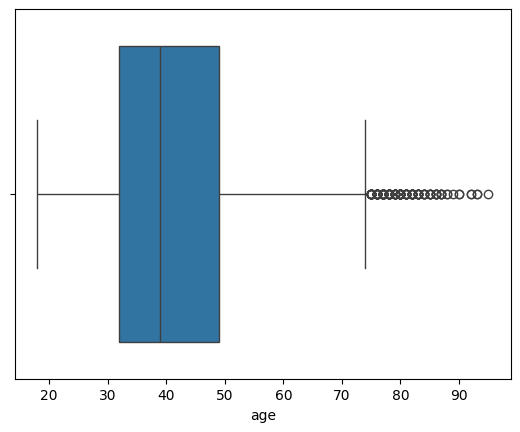

In [21]:
# outlier age (edad del cliente)
sns.boxplot(data=df, x="age")

# según describe(), el valor mínimo de age es 0 y el máximo 95. En este caso podríamos considerar que los valores 0 no son correctos.
# los podríamos sustituir por un valor fijo, o por ejemplo por la media del resto de valores.

# valor fijo:
#df['age']=df['age'].replace(0,35)
#df.describe()

# media del resto de valores sin considerar los 0 que hayan
ageSinCeros=df[df['age']!=0]['age']
mediaAge=ageSinCeros.mean().round(2)
df['age']=df['age'].replace(0,mediaAge)

<Axes: xlabel='balance'>

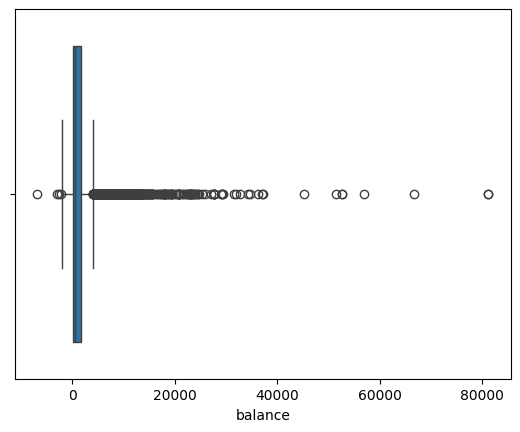

In [22]:
# outlier balance (saldo medio anual del cliente: puede ser negativo o positivo)
sns.boxplot(data=df, x="balance")

<Axes: xlabel='day'>

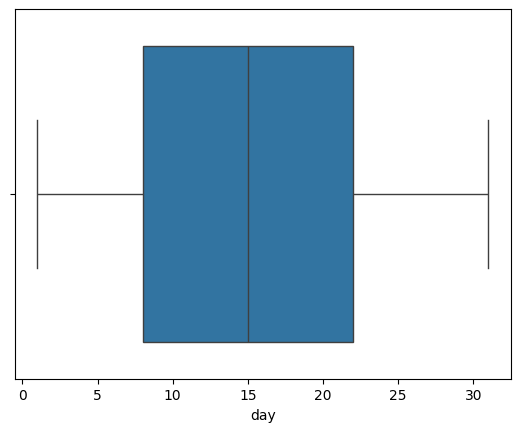

In [23]:
# outlier day (último día de la semana que se contacta con el cliente: de 1 a 31)
sns.boxplot(data=df, x="day")

<Axes: xlabel='duration'>

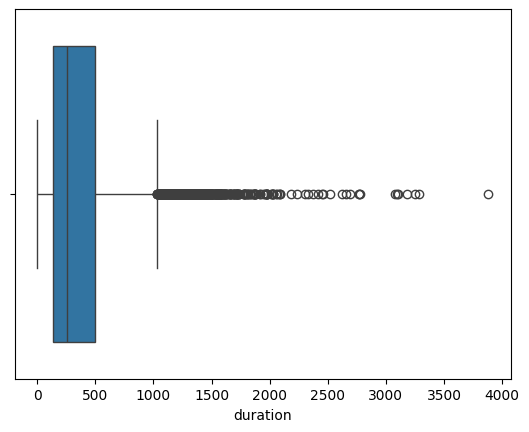

In [24]:
# outlier duration (duración en seg. del último contacto telefónico con el cliente. Si es 0 entonces la variable y debe ser 0)
sns.boxplot(data=df, x="duration")

# convertir los segundos a minutos.
# sobre la misma columna:
# df['duration']=df['duration']/60

# generando el calculo en una nueva columna:
# df.insert(13,'durationMin',df['duration']/60)
# df.describe()

<Axes: xlabel='campaign'>

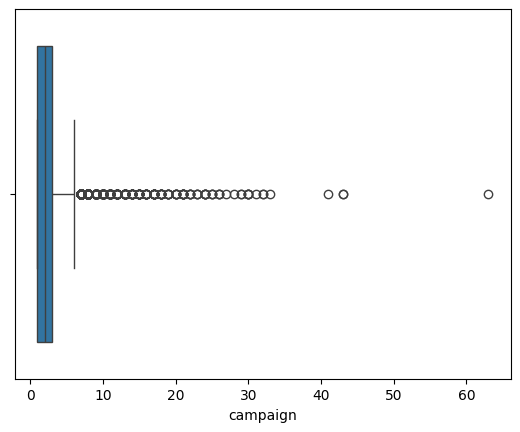

In [26]:
# outlier campaign (número de llamadas para esta campaña)
sns.boxplot(data=df, x="campaign")

# buscar si hay algún patrón con los contactados más de 10 veces?
# df.loc[df['campaign']>10]

# para eliminar registros a partir de un determinado valor
# print(f'Tamaño antes de eliminar filas repetidas: {df.shape}')
# df=df[df['campaign']>10]
# print(f'Tamaño después de eliminar filas repetidas: {df.shape}')

<Axes: xlabel='pdays'>

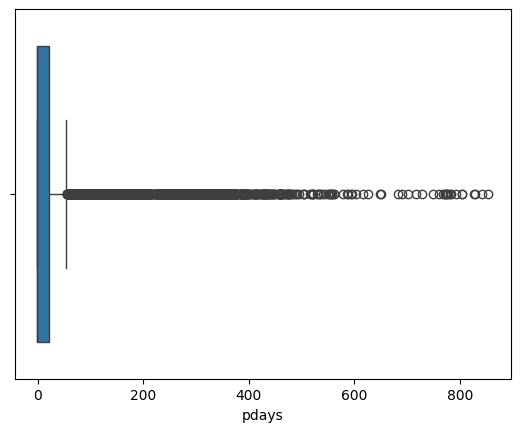

In [27]:
# outlier pdays (días transcurridos desde la última llamada al cliente en campañas anteriores. si es -1 significa que no se contactó previamente con el cliente)
sns.boxplot(data=df, x="pdays")

<Axes: xlabel='previous'>

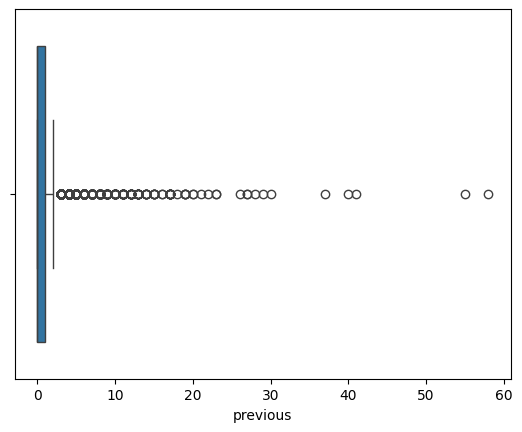

In [28]:
# outlier previous (contactos realizados para campañas anteriores al cliente)
sns.boxplot(data=df, x="previous")

<span style="color: rgba(230, 0, 126, 1);"> 4.5-Errores tipográficos en caso de variables categóricas </span>

In [ ]:
# gráficas de barras para las variables categóricas y comprobar si hay valores similares escritos diferente y cuanto aparecen en el data set
df.info()

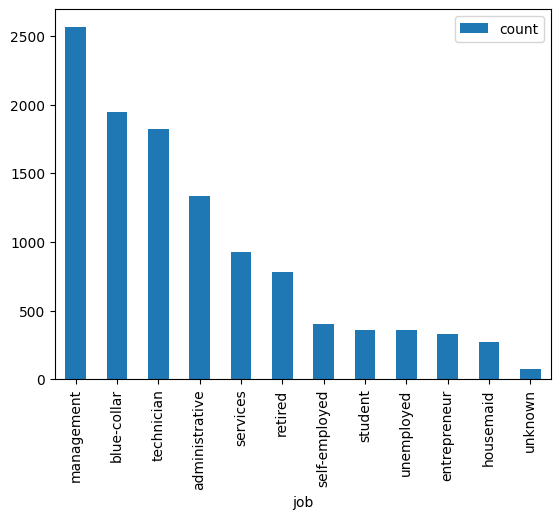

In [ ]:
# gráficas de barras para job (trabajo del usuario)
pd.DataFrame(df["job"].value_counts()).plot.bar()

# quizás reemplazar el único trabajo abreviado admin. por administration
df['job']=df['job'].str.replace('admin.','administrative',regex=False)

<Axes: xlabel='marital'>

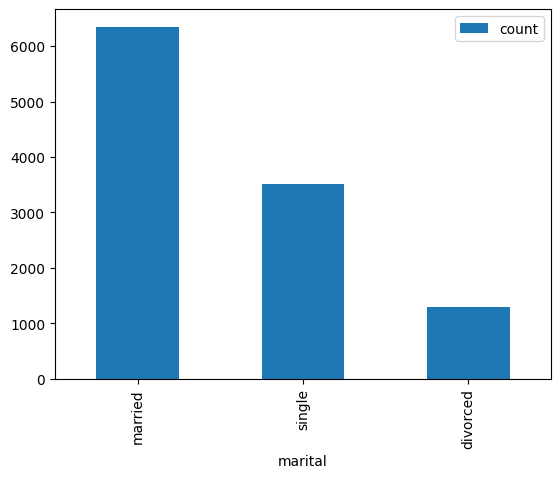

In [ ]:
# gráficas de barras para marital (estado civil del usuario)
pd.DataFrame(df["marital"].value_counts()).plot.bar() 

<Axes: xlabel='education'>

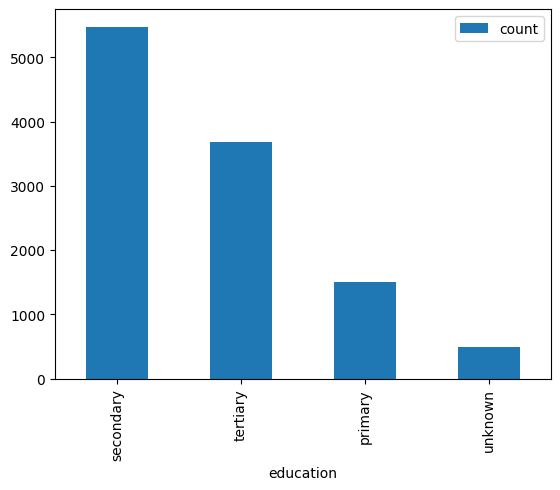

In [ ]:
# gráficas de barras para education (nivel de educación del usuario)
pd.DataFrame(df["education"].value_counts()).plot.bar() 

<Axes: xlabel='default'>

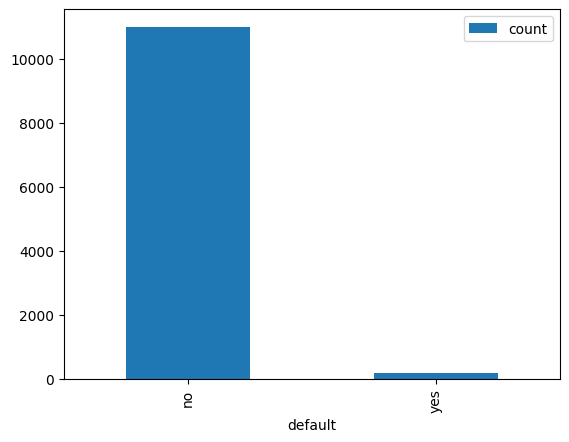

In [ ]:
# gráficas de barras para default (indica si el usuario tiene créditos impagados)
pd.DataFrame(df["default"].value_counts()).plot.bar() 

<Axes: xlabel='housing'>

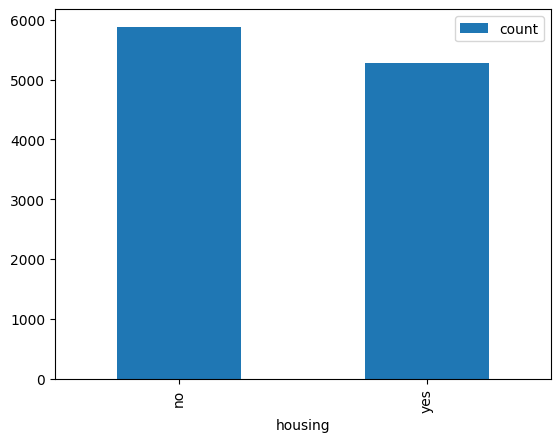

In [ ]:
# gráficas de barras para housing (indica si el usuario tiene un crédito de vivienda)
pd.DataFrame(df["housing"].value_counts()).plot.bar() 

<Axes: xlabel='loan'>

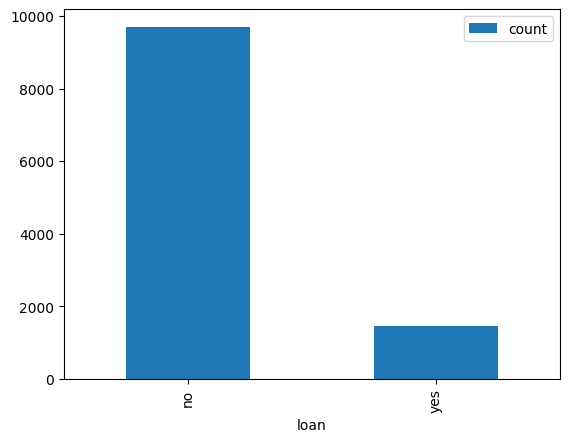

In [ ]:
# gráficas de barras para loan (indica si el usuario tiene un crédito personal)
pd.DataFrame(df["loan"].value_counts()).plot.bar() 

<Axes: xlabel='contact'>

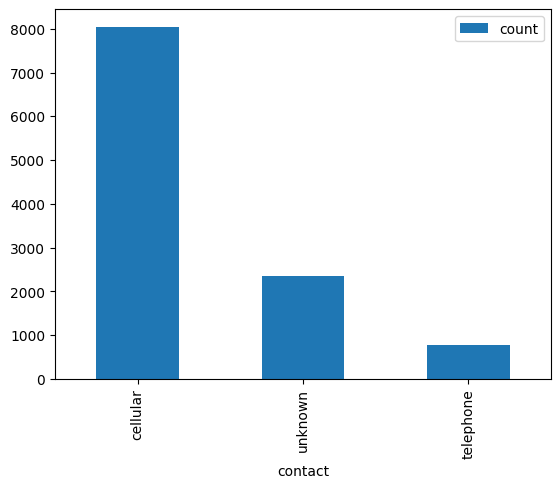

In [ ]:
# gráficas de barras para contact (forma de contacto con el usuario)
pd.DataFrame(df["contact"].value_counts()).plot.bar() 

<Axes: xlabel='month'>

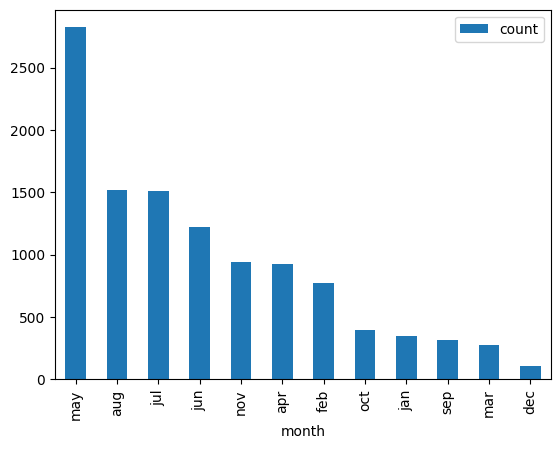

In [ ]:
# gráficas de barras para month (mes en el que se realizó el último contacto con el usuario)
pd.DataFrame(df["month"].value_counts()).plot.bar() 

<Axes: xlabel='poutcome'>

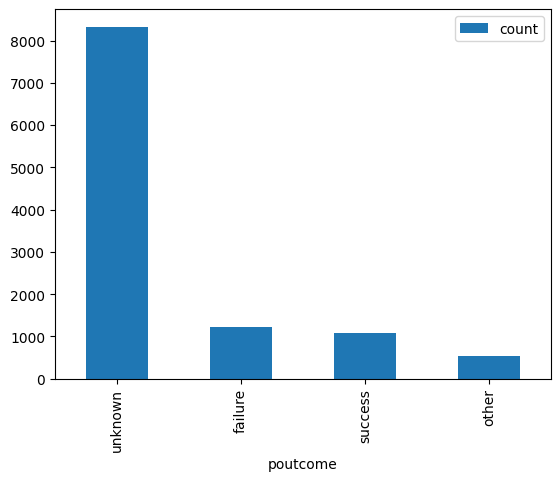

In [ ]:
# gráficas de barras para poutcome (resultado de la campaña de marketing anterior a la actual)
pd.DataFrame(df["poutcome"].value_counts()).plot.bar() 

<Axes: xlabel='deposit'>

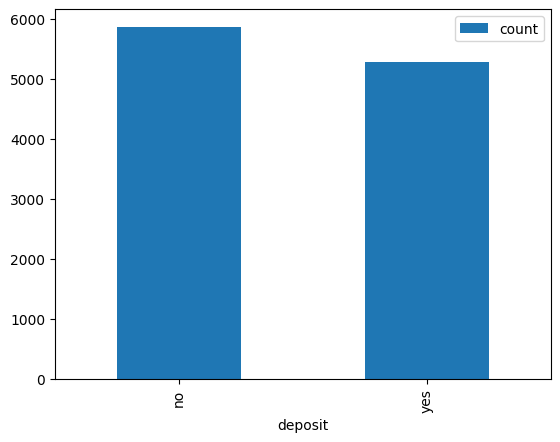

In [ ]:
# gráficas de barras para deposit (indica si el usuario ha contratado un depósito a plazo fijo)
pd.DataFrame(df["deposit"].value_counts()).plot.bar() 

### <span style="color: rgba(230, 0, 126, 1);"> 5.- Exportación a csv </span> ###

In [30]:
df.to_csv(r"C:\MNG\03_IT Academy\04_Simulador empresarial (SE)\ProjecteData\251027_MNG_W01\281027_tabla BANK_marketing(cleaned v1).csv",sep=";",index=False)